Test

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_1 = pd.read_excel('/Users/hendrikalbrecht/Dokumente/Z_Übungen/Mavenanalytics/Manufacturing Downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line productivity')

In [4]:
df_2 = pd.read_excel('/Users/hendrikalbrecht/Dokumente/Z_Übungen/Mavenanalytics/Manufacturing Downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Products')
df_3 = pd.read_excel('/Users/hendrikalbrecht/Dokumente/Z_Übungen/Mavenanalytics/Manufacturing Downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Downtime factors')
df_4 = pd.read_excel('/Users/hendrikalbrecht/Dokumente/Z_Übungen/Mavenanalytics/Manufacturing Downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line downtime')

In [5]:
df_1.head()

,Date,Product,Batch,Operator,Start Time,End Time
0,2024-08-29,OR-600,422111,Mac,11:50:00,14:05:00
1,2024-08-29,LE-600,422112,Mac,14:05:00,15:45:00
2,2024-08-29,LE-600,422113,Mac,15:45:00,17:35:00
3,2024-08-29,LE-600,422114,Mac,17:35:00,19:15:00
4,2024-08-29,LE-600,422115,Charlie,19:15:00,20:39:00


In [6]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        38 non-null     datetime64[us]
 1   Product     38 non-null     str           
 2   Batch       38 non-null     int64         
 3   Operator    38 non-null     str           
 4   Start Time  38 non-null     object        
 5   End Time    38 non-null     object        
dtypes: datetime64[us](1), int64(1), object(2), str(2)
memory usage: 1.9+ KB


In [7]:
df_1['Operator']

0         Mac
1         Mac
2         Mac
3         Mac
4     Charlie
5     Charlie
6     Charlie
7         Dee
8         Dee
9         Dee
10     Dennis
11     Dennis
12     Dennis
13     Dennis
14    Charlie
15    Charlie
16    Charlie
17    Charlie
18    Charlie
19        Dee
20        Dee
21        Dee
22        Dee
23        Mac
24        Mac
25        Mac
26        Dee
27        Dee
28        Dee
29        Dee
30     Dennis
31     Dennis
32     Dennis
33     Dennis
34    Charlie
35    Charlie
36    Charlie
37        Mac
Name: Operator, dtype: str

In [8]:
df_2.head()

,Product,Flavor,Size,Min batch time
0,OR-600,Orange,600 ml,60
1,LE-600,Lemon lime,600 ml,60
2,CO-600,Cola,600 ml,60
3,DC-600,Diet Cola,600 ml,60
4,RB-600,Root Beer,600 ml,60


In [9]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Product         6 non-null      str  
 1   Flavor          6 non-null      str  
 2   Size            6 non-null      str  
 3   Min batch time  6 non-null      int64
dtypes: int64(1), str(3)
memory usage: 324.0 bytes


In [10]:
df_3.head()

,Factor,Description,Operator Error
0,1,Emergency stop,No
1,2,Batch change,Yes
2,3,Labeling error,No
3,4,Inventory shortage,No
4,5,Product spill,Yes


In [11]:
df_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Factor          12 non-null     int64
 1   Description     12 non-null     str  
 2   Operator Error  12 non-null     str  
dtypes: int64(1), str(2)
memory usage: 420.0 bytes


In [12]:
df_4.head()

,Unnamed: 0,Downtime factor,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Batch,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
1,422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN
2,422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
3,422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# 1. Erste Zeile aus df_4 als neue Spaltennamen setzen
df_4_clean = df_4.copy()

df_4_clean.columns = df_4_clean.iloc[0]
df_4_clean = df_4_clean.iloc[1:].reset_index(drop=True)

# 2. Faktor-Mapping aus df_3 erstellen
factor_map = dict(zip(df_3["Factor"], df_3["Description"]))

# 3. Spaltennamen vorbereiten und umbenennen
new_columns = []

for col in df_4_clean.columns:
    # Batch-Spalte behalten
    if col == "Batch":
        new_columns.append("Batch")
    else:
        # aus 1.0 -> 1 machen
        factor_number = int(float(col))
        new_columns.append(factor_map[factor_number])

df_4_clean.columns = new_columns

# 4. Werte numerisch machen, außer Batch
for col in df_4_clean.columns:
    if col != "Batch":
        df_4_clean[col] = pd.to_numeric(df_4_clean[col], errors="coerce")

df_4_clean.head()

,Batch,Emergency stop,Batch change,Labeling error,Inventory shortage,Product spill,Machine adjustment,Machine failure,Batch coding error,Conveyor belt jam,Calibration error,Label switch,Other
0,422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN
1,422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
2,422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN
4,422115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN


In [14]:
df_4_clean.isna().sum()

Batch                  0
Emergency stop        38
Batch change          33
Labeling error        36
Inventory shortage    29
Product spill         35
Machine adjustment    26
Machine failure       27
Batch coding error    32
Conveyor belt jam     37
Calibration error     35
Label switch          35
Other                 32
dtype: int64

In [15]:
# NaN Werte mit '0' füllen

df_4_clean = df_4_clean.fillna(0)
df_4_clean

,Batch,Emergency stop,Batch change,Labeling error,Inventory shortage,Product spill,Machine adjustment,Machine failure,Batch coding error,Conveyor belt jam,Calibration error,Label switch,Other
0,422111,0.0,60.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0
1,422112,0.0,20.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0
2,422113,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,422114,0.0,0.0,0.0,25.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0
4,422115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0
5,422116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,422117,0.0,10.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
7,422118,0.0,0.0,0.0,0.0,0.0,14.0,16.0,0.0,0.0,0.0,10.0,20.0
8,422119,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,422120,0.0,0.0,0.0,20.0,15.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0


In [16]:
df_4_clean.isna().sum()

Batch                 0
Emergency stop        0
Batch change          0
Labeling error        0
Inventory shortage    0
Product spill         0
Machine adjustment    0
Machine failure       0
Batch coding error    0
Conveyor belt jam     0
Calibration error     0
Label switch          0
Other                 0
dtype: int64

In [17]:
# Berechnen total downtime per batch

df_4_clean["Total_Downtime"] = df_4_clean.drop(columns="Batch").sum(axis=1)

df_4_clean.head()

,Batch,Emergency stop,Batch change,Labeling error,Inventory shortage,Product spill,Machine adjustment,Machine failure,Batch coding error,Conveyor belt jam,Calibration error,Label switch,Other,Total_Downtime
0,422111,0.0,60.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,75.0
1,422112,0.0,20.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,40.0
2,422113,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
3,422114,0.0,0.0,0.0,25.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0
4,422115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,24.0


In [18]:
df_4_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Batch               38 non-null     object 
 1   Emergency stop      38 non-null     float64
 2   Batch change        38 non-null     float64
 3   Labeling error      38 non-null     float64
 4   Inventory shortage  38 non-null     float64
 5   Product spill       38 non-null     float64
 6   Machine adjustment  38 non-null     float64
 7   Machine failure     38 non-null     float64
 8   Batch coding error  38 non-null     float64
 9   Conveyor belt jam   38 non-null     float64
 10  Calibration error   38 non-null     float64
 11  Label switch        38 non-null     float64
 12  Other               38 non-null     float64
 13  Total_Downtime      38 non-null     float64
dtypes: float64(13), object(1)
memory usage: 4.3+ KB


Letzte Spalte von df_4_clean zu df_1 addieren/kopieren

In [19]:
df_1['Total_Downtime'] = df_4_clean['Total_Downtime']

In [20]:
df_1.columns

Index(['Date', 'Product', 'Batch', 'Operator', 'Start Time', 'End Time',
       'Total_Downtime'],
      dtype='str')

In [21]:
df_1.head()

,Date,Product,Batch,Operator,Start Time,End Time,Total_Downtime
0,2024-08-29,OR-600,422111,Mac,11:50:00,14:05:00,75.0
1,2024-08-29,LE-600,422112,Mac,14:05:00,15:45:00,40.0
2,2024-08-29,LE-600,422113,Mac,15:45:00,17:35:00,50.0
3,2024-08-29,LE-600,422114,Mac,17:35:00,19:15:00,40.0
4,2024-08-29,LE-600,422115,Charlie,19:15:00,20:39:00,24.0


#

1. Frage Line efficiency Groupby Product
3. Frage Leading factors -> df_4_clean spalten addieren, dann absteigend sortieren (grösstes zuerst)
2. Frage operators underperforming (nach operators gruppieren (mac, charlie), avg downtime, vergleichen mit avg., dann gucken wer unter und wer über avg. liegt
4. Frage Do operators struggle with particular operator error | operator error J/N (df_3) | df_4 zwei neue spalten J oder N, füllen mit der jeweiligen downtime | zuordnen wieviel zeit operator downtime bzw. maschinelle downtime | df_1 breakdown 75 minuten total downtime (anteil maschinell, anteil human) | per operator gruppieren (mac 100 minuten human, 10 minuten maschinell)
5. Natalia macht Frage 1 + 3, Hendrik macht 2 + 4


In [ ]:
"""
Question #2
Are any operators underperforming?
Possible KPIs
 - average batch time by operator
 - average batchtime overall
 - productivity by operator
 - defect/error rate
"""

In [ ]:
"""
Question #4
Do any operators struggle with a particular operator error?
Possible KPIs
 - which error with which operator
 - how much time per operator
"""

df_1 = Haupttabelle
df_3 = Ursachen-Lexikon
df_4_clean = Downtime Details

Total_Downtime = Dauer
Downtime_Count = Häufigkeit

In [ ]:
"""
Question 2:
df_1 = Line Productivity
Are any operators underperforming?

Group by operator
Analyze column Total_Downtime
Calculate mean, sum (total downtime) and count of batches
Count = Number of batches per operator, NOT number of downtimes!!
Sort by mean in descending order (highest first)
"""
df_1.groupby('Operator')['Total_Downtime'].agg(["mean", "sum", "count"]).sort_values("mean", ascending=False)


,mean,sum,count
Operator,,,
Mac,41.500000,332.0,8
Dennis,37.750000,302.0,8
Charlie,34.909091,384.0,11
Dee,33.636364,370.0,11


Based on average downtime per batch, Mac appears to be the weakest-performing operator with 41.5 minutes of downtime per batch, followed by Dennis with 37.75 minutes. Charlie recorded the highest total downtime overall, but also handled more batches, making average downtime the fairer comparison metric. Mac may require additional support, training, or process review to reduce downtime and align performance with peers.

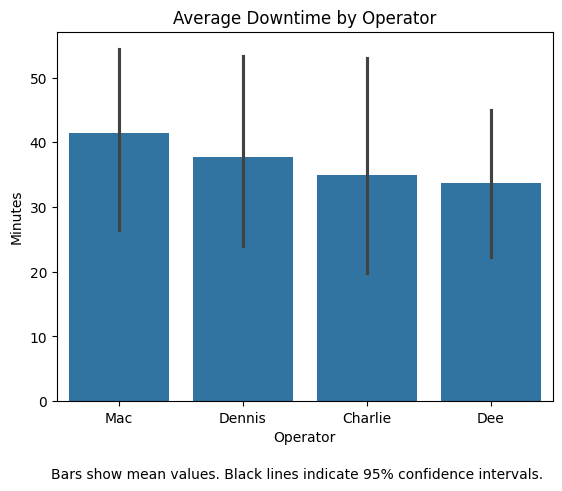

In [41]:
sns.barplot(data=df_1, x="Operator", y="Total_Downtime", estimator="mean", order=["Mac", "Dennis", "Charlie", "Dee"])

plt.title("Average Downtime by Operator")
plt.ylabel("Minutes")

plt.figtext(

    0.5, -0.05,

    "Bars show mean values. Black lines indicate 95% confidence intervals.",

    ha="center",

    fontsize=10

)

plt.show()

We are 95% confident that the true average downtime for Mac lies roughly between 27 and 54 minutes.

In [ ]:
# Create a list of downtime factor columns by excluding Batch and Total_Downtime.
# Then count how many downtime factors were greater than zero in each batch.

# This creates a new column:
# Downtime_Count = number of downtime events per batch

# Count how many different downtime events occurred in each batch.

downtime_columns = df_4_clean.drop(
    columns=["Batch", "Total_Downtime"]
).columns

df_4_clean["Downtime_Count"] = (
    df_4_clean[downtime_columns] > 0
).sum(axis=1)

In [ ]:
# Display the first rows to verify the new column.

# Compare:
# - Total_Downtime = total minutes lost
# - Downtime_Count = number of downtime events

df_4_clean[["Batch", "Total_Downtime", "Downtime_Count"]].head()

,Batch,Total_Downtime,Downtime_Count
0,422111,75.0,2
1,422112,40.0,2
2,422113,50.0,1
3,422114,40.0,2
4,422115,24.0,1


In [ ]:
# Add Downtime_Count to the main productivity table (df_1)
# so operator-level analysis can be performed.

df_1["Downtime_Count"] = df_4_clean["Downtime_Count"]

This allows us to compare operators not only by downtime duration,
but also by frequency of downtime events.

In [28]:
# Calculate the average, total, and number of downtime events per operator.
# This helps identify operators with more frequent disruptions.

df_1.groupby("Operator")["Downtime_Count"].agg(
    ["mean", "sum", "count"]
).sort_values("mean", ascending=False)

,mean,sum,count
Operator,,,
Dee,1.727273,19,11
Mac,1.625000,13,8
Charlie,1.545455,17,11
Dennis,1.500000,12,8


Mac records the highest average downtime duration, while Dee experiences the highest average number of downtime events per batch.

This suggests that Mac’s downtime incidents may last longer, whereas Dee experiences more frequent but shorter disruptions.

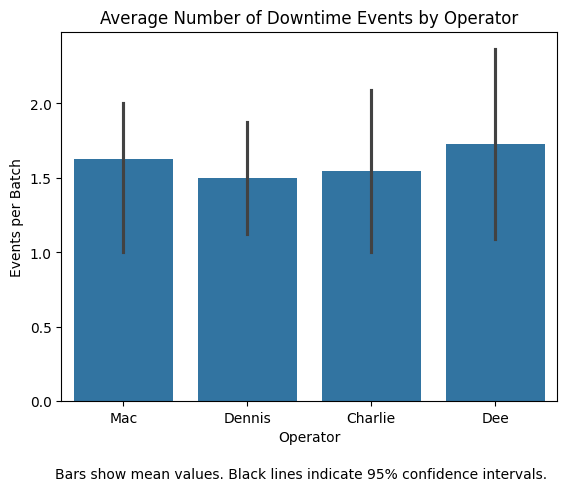

In [42]:
sns.barplot(
    data=df_1,
    x="Operator",
    y="Downtime_Count",
    estimator="mean",
    order=["Mac", "Dennis", "Charlie", "Dee"]
)

plt.title("Average Number of Downtime Events by Operator")
plt.ylabel("Events per Batch")

plt.figtext(

    0.5, -0.05,

    "Bars show mean values. Black lines indicate 95% confidence intervals.",

    ha="center",

    fontsize=10

)
plt.show()

In [38]:
summary_table = df_1.groupby("Operator").agg(
    Avg_Downtime_Minutes=("Total_Downtime", "mean"),
    Avg_Downtime_Events=("Downtime_Count", "mean")
).round(2)

summary_table

,Avg_Downtime_Minutes,Avg_Downtime_Events
Operator,,
Charlie,34.91,1.55
Dee,33.64,1.73
Dennis,37.75,1.50
Mac,41.50,1.62


In [39]:
summary_table["Interpretation"] = [
    "Balanced performance",
    "Frequent short disruptions",
    "Moderate downtime, low event count",
    "Longer downtime incidents"
]

summary_table

,Avg_Downtime_Minutes,Avg_Downtime_Events,Interpretation
Operator,,,
Charlie,34.91,1.55,Balanced performance
Dee,33.64,1.73,Frequent short disruptions
Dennis,37.75,1.50,"Moderate downtime, low event count"
Mac,41.50,1.62,Longer downtime incidents


In [40]:
summary_table = summary_table.loc[
    ["Mac", "Dennis", "Charlie", "Dee"]
]
summary_table

,Avg_Downtime_Minutes,Avg_Downtime_Events,Interpretation
Operator,,,
Mac,41.50,1.62,Longer downtime incidents
Dennis,37.75,1.50,"Moderate downtime, low event count"
Charlie,34.91,1.55,Balanced performance
Dee,33.64,1.73,Frequent short disruptions


This summary compares downtime duration and frequency by operator.
It helps identify whether issues are caused by long stoppages or frequent disruptions.